In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error as mse

np.random.seed(0)

In [4]:
df_train = pd.read_csv("/Users/ekaterinaleontieva/test/regression_train-1.csv")
df_test = pd.read_csv("/Users/ekaterinaleontieva/test/regression_test-1.csv")
X_train = df_train["x"].values.reshape(-1,1)
y_train = df_train["y"].values.reshape(-1,1)

X_test = df_test["x"].values.reshape(-1,1)
y_test = df_test["y"].values.reshape(-1,1)

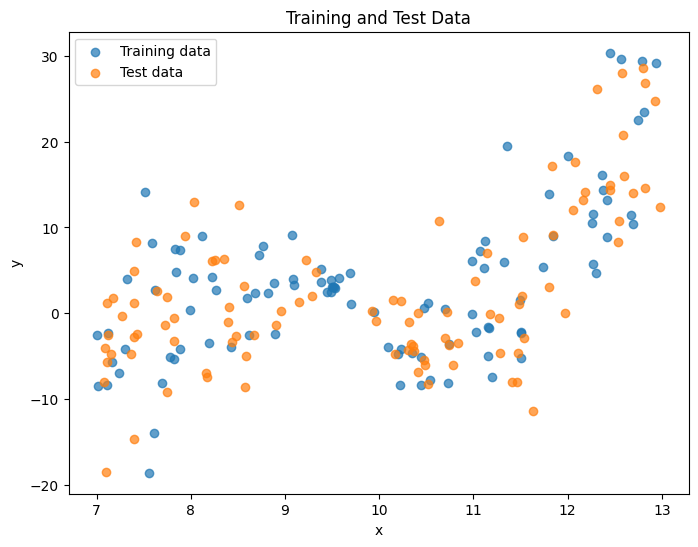

In [5]:
plt.figure(figsize=(8,6))
plt.scatter(X_train, y_train, label="Training data", alpha=0.7)
plt.scatter(X_test, y_test, label="Test data", alpha=0.7)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Training and Test Data")
plt.legend()

plt.show()

In [7]:
poly = PolynomialFeatures(degree=1)

Phi_train = poly.fit_transform(X_train)
Phi_test = poly.transform(X_test)

In [8]:
model = LinearRegression()
model.fit(Phi_train, y_train)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: [-24.28226663]
Coefficients: [[0.         2.78327901]]


In [9]:
y_train_pred = model.predict(Phi_train)
y_test_pred = model.predict(Phi_test)

train_risk = mse(y_train, y_train_pred)
test_risk = mse(y_test, y_test_pred)

print("Training risk:", train_risk)
print("Test risk:", test_risk)

Training risk: 59.85412299873804
Test risk: 63.262766999620425


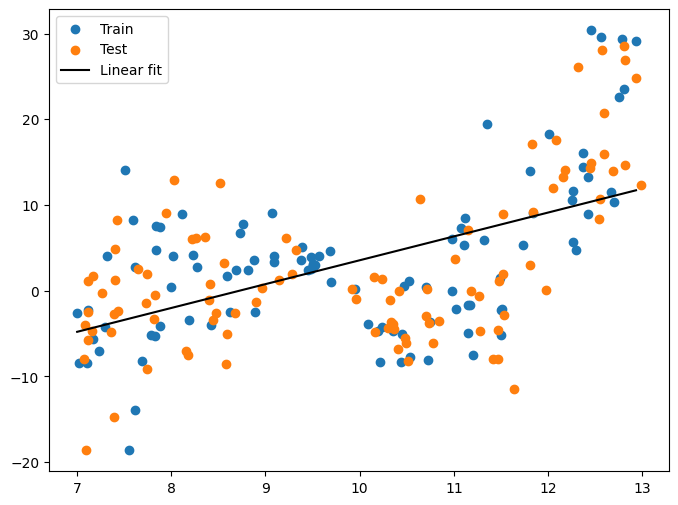

In [10]:
x_grid = np.linspace(X_train.min(), X_train.max(), 200).reshape(-1,1)
x_grid_phi = poly.transform(x_grid)

plt.figure(figsize=(8,6))

plt.scatter(X_train, y_train, label="Train")
plt.scatter(X_test, y_test, label="Test")

plt.plot(x_grid, model.predict(x_grid_phi), color="black", label="Linear fit")

plt.legend()
plt.show()

In [11]:
def GD(Phi, y, T, eta):

    n, d = Phi.shape
    beta = np.zeros((d,1))

    beta_hist = []
    J_hist = []

    for t in range(T):

        gradient = (2/n) * Phi.T @ (Phi @ beta - y)
        beta = beta - eta * gradient

        J = (1/n) * np.linalg.norm(y - Phi @ beta)**2

        beta_hist.append(beta.copy())
        J_hist.append(J)

    return beta_hist, J_hist

In [12]:
beta_hist, J_hist = GD(Phi_train, y_train, T=500, eta=0.005)

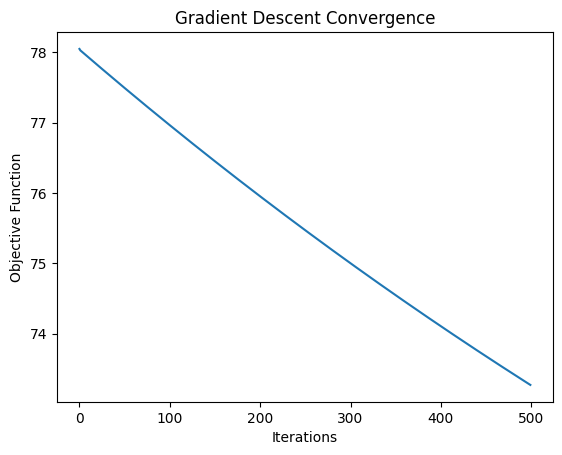

In [13]:
plt.plot(J_hist)
plt.xlabel("Iterations")
plt.ylabel("Objective Function")
plt.title("Gradient Descent Convergence")

plt.show()

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
def SGD(Phi, y, T):

    n, d = Phi.shape
    beta = np.zeros((d,1))

    J_hist = []

    for t in range(1, T):

        i = np.random.randint(n)

        phi_i = Phi[i].reshape(-1,1)
        y_i = y[i]

        eta = 0.1 / (t**0.9)

        gradient = 2 * phi_i * (phi_i.T @ beta - y_i)

        beta = beta - eta * gradient

        J = (1/n) * np.linalg.norm(y - Phi @ beta)**2
        J_hist.append(J)

    return beta, J_hist

In [16]:
degrees = range(10)

train_risks = []
test_risks = []

for M in degrees:

    poly = PolynomialFeatures(degree=M)

    Phi_train = poly.fit_transform(X_train)
    Phi_test = poly.transform(X_test)

    model = LinearRegression()
    model.fit(Phi_train, y_train)

    train_risks.append(mse(y_train, model.predict(Phi_train)))
    test_risks.append(mse(y_test, model.predict(Phi_test)))

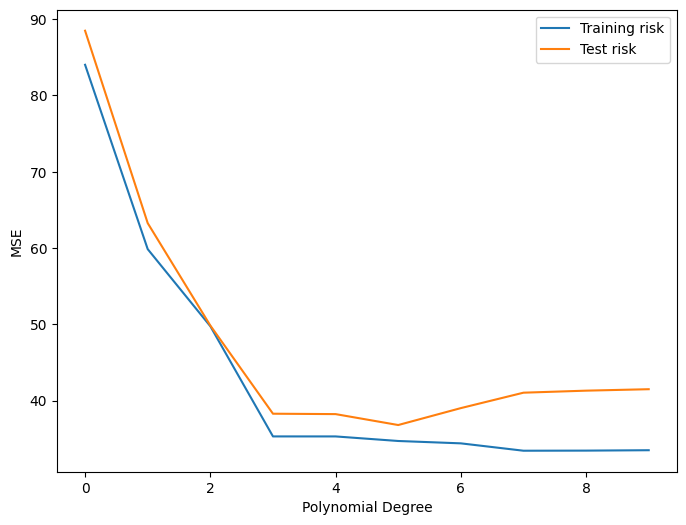

In [17]:
plt.figure(figsize=(8,6))

plt.plot(degrees, train_risks, label="Training risk")
plt.plot(degrees, test_risks, label="Test risk")

plt.xlabel("Polynomial Degree")
plt.ylabel("MSE")

plt.legend()
plt.show()

In [18]:
lambdas = np.logspace(-4,4,50)

train_risks = []
test_risks = []

poly = PolynomialFeatures(degree=12)

Phi_train = poly.fit_transform(X_train)
Phi_test = poly.transform(X_test)

for lam in lambdas:

    model = Ridge(alpha=lam)
    model.fit(Phi_train, y_train)

    train_risks.append(mse(y_train, model.predict(Phi_train)))
    test_risks.append(mse(y_test, model.predict(Phi_test)))

/Users/ekaterinaleontieva/opt/anaconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=2.17193e-32): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/ekaterinaleontieva/opt/anaconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=3.40369e-32): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/ekaterinaleontieva/opt/anaconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=5.01314e-32): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/ekaterinaleontieva/opt/anaconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=7.36328e-32): result may not be

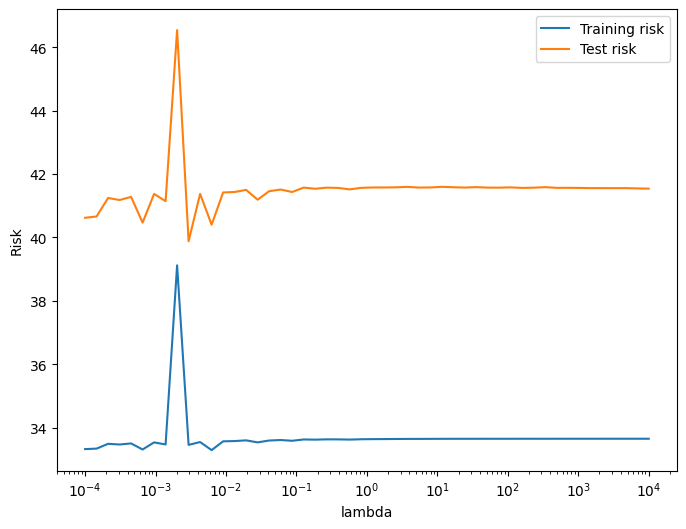

In [19]:
plt.figure(figsize=(8,6))

plt.semilogx(lambdas, train_risks, label="Training risk")
plt.semilogx(lambdas, test_risks, label="Test risk")

plt.xlabel("lambda")
plt.ylabel("Risk")

plt.legend()
plt.show()

In [20]:
def legendre_features(X, M):

    legend_reg_transform = lambda x: np.polynomial.legendre.legvander((x-10)/3, deg=M)
    return legend_reg_transform(X.reshape(-1,1)).squeeze()

In [21]:
degrees = range(1,200)

train_risk = []
test_risk = []
beta_norm = []

for M in degrees:

    Phi_train = legendre_features(X_train, M)
    Phi_test = legendre_features(X_test, M)

    model = LinearRegression()
    model.fit(Phi_train, y_train)

    train_risk.append(mse(y_train, model.predict(Phi_train)))
    test_risk.append(mse(y_test, model.predict(Phi_test)))

    beta_norm.append(np.linalg.norm(model.coef_))

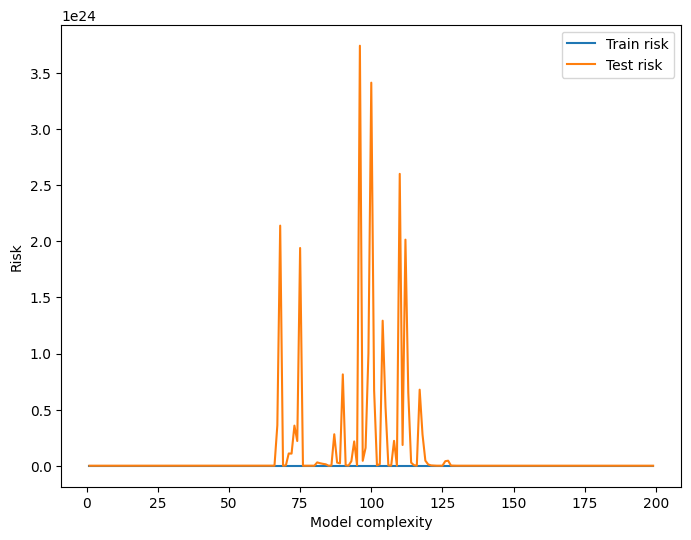

In [22]:
plt.figure(figsize=(8,6))

plt.plot(degrees, train_risk, label="Train risk")
plt.plot(degrees, test_risk, label="Test risk")

plt.xlabel("Model complexity")
plt.ylabel("Risk")

plt.legend()
plt.show()